In [26]:
# autoload and reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import sys  
sys.path.insert(1, '..')

In [28]:
from pathlib import Path
import pyroomacoustics as pra
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from tqdm import tqdm

from scipy.io import wavfile
from mir_eval.separation import bss_eval_images

from einops import rearrange, repeat

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from geo_utils import get_wall_order_from_images, distance
from max_sinr_beamforming import compute_gain

from beamformers import (
    mvdr_weights, 
    delay_and_sum_weights, 
    souden_weights, 
    max_sinr_weights, 
    lcmv_weights,
    rake_weights,
    compute_steering_vector
)

import pandas as pd

In [29]:
SIR = 0
SNR = 20
noise_loc_options = "doa_speech"

N_IMAGES_PERFORMANCE = 30
VAD_GUARD = 1024
RT60 = 0.712 # seconds [or 0.300]

mic = "pyramic"
SIR_file = 5
nfft = 1024

bf_criterion = "lcmv"
bf_criterion = "mvdr"
bf_criterion = "maxsinr"
bf_criterion = "matched"

In [30]:
results_dict_image = {
    'SIR': SIR,
    'SIR_file': SIR_file,
    'N_IMAGES_PERFORMANCE': N_IMAGES_PERFORMANCE,
    'nfft': nfft,
    'VAD_GUARD': VAD_GUARD,
    'bf_criterion': bf_criterion,
}
results_dict_doa = results_dict_image.copy()

Settings

In [ ]:
# Set folders
experiment_folder = "../datanet/projects/otohikari/robin/measurements/20171207"
file_pattern = os.path.join(experiment_folder, "segmented/{}_{}_SIR_{}_dB.wav")
file_speech_ref = os.path.join(experiment_folder, "segmented/{}_speech_ref.wav")
protocol_file = os.path.join(experiment_folder, "protocol.json")

In [32]:
# Load the protocol and settings
with open(protocol_file, "r") as f:
    protocol = json.load(f)


sir_choices = [5, 10, 15, 20, 25]
mic_choices = {"olympus": "camera_audio", "pyramic": "pyramic_audio"}
mics_geom = {
    "pyramic": np.array(protocol["geometry"]["microphones"]["pyramic"]["locations"]),
    "olympus": np.array(protocol["geometry"]["microphones"]["olympus"]["locations"]),
}

In [33]:
# Get the locations of the microphones
mics_loc = np.array(protocol["geometry"]["microphones"][mic]["reference"])
noise_loc = protocol["geometry"]["speakers"]["locations"][0]
speech_loc = protocol["geometry"]["speakers"]["locations"][1]
room_dim = protocol["geometry"]["room"]

if mic == "pyramic":
    I = list(range(8, 16)) + list(range(24, 32)) + list(range(40, 48))  # flat part
    mics_positions = mics_geom["pyramic"][I].copy()
    # place in room 2-806
    mics_positions -= np.mean(mics_positions, axis=0)[None, :]
    mics_positions[:, 2] -= np.max(mics_positions[:, 2])
    mics_positions += mics_loc

elif mic == "olympus":
    mics_positions = mics_geom["olympus"].copy() + mics_loc
    
print("Room dimensions: ", room_dim)

Room dimensions:  [8.945, 7.421, 2.6]


In [34]:
# Read the mix signals
fs_led, leds = wavfile.read(
    file_pattern.format("camera_leds_zero_hold", "mix", SIR_file)
)
fs_snd, mix = wavfile.read(file_pattern.format(mic_choices[mic], "mix", SIR_file))
assert fs_led == fs_snd

In [35]:
# read in the ref signals
r, noise_ref = wavfile.read(file_pattern.format(mic_choices[mic], "noise_ref", SIR_file))
assert r == fs_snd
r, speech_ref = wavfile.read(file_speech_ref.format(mic_choices[mic]))
assert r == fs_snd
r, leds_ref = wavfile.read(file_speech_ref.format("camera_leds_zero_hold"))
assert r == fs_snd
fs = fs_snd # shorthand

# remove DC component
speech_ref = speech_ref - np.mean(speech_ref, axis=0)
noise_ref = noise_ref - np.mean(noise_ref, axis=0)

# high pass filter
speech_ref = pra.highpass(speech_ref.astype(float), r, fc=80)
noise_ref = pra.highpass(noise_ref.astype(float), r, fc=80)

speech_ref = speech_ref[:,0]
noise_ref = noise_ref[:,0]

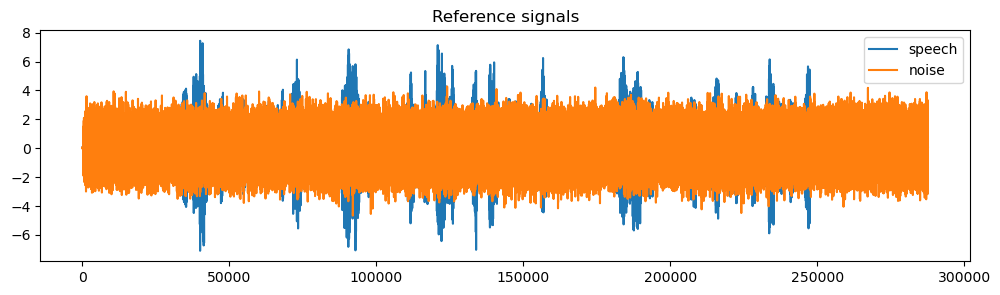

In [36]:
# Reference signals
speech_ref = speech_ref / np.std(speech_ref)
noise_ref = noise_ref / np.std(noise_ref)

# scale the speech ref signal according to the SIR in dB
speech_ref *= 10 ** (SIR / 20)

plt.figure(figsize=(12, 3))
plt.plot(speech_ref, label="speech")
plt.plot(noise_ref, label="noise")
plt.legend()
plt.title("Reference signals")
plt.show()

Set up the room

absorption =  0.1792592990982637
max_order =  99


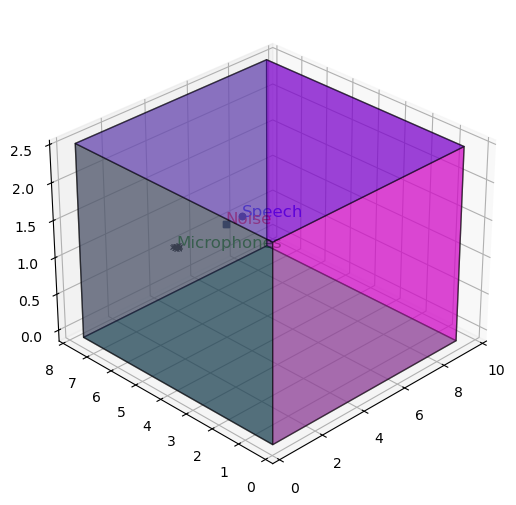

In [37]:
# Create the room and plot it
rt60 = RT60 # seconds. A dummy value for now
e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)

# max_order = 1

print("absorption = ", e_absorption)
print("max_order = ", max_order)

room = pra.ShoeBox(room_dim, fs=fs, materials=pra.Material(e_absorption), max_order=max_order)
room.add_source(speech_loc, signal=speech_ref) # speech
room.sources[-1].name = 'target'
if noise_loc_options == 'doa_speech':
    noise_loc = speech_loc
    noise_loc = noise_loc - np.array([0.8, 0, 0])
    
elif noise_loc_options == 'doa_noise':
    noise_loc = noise_loc
    
room.add_source(noise_loc, signal=noise_ref) # noise
room.sources[-1].name = 'interf'
room.add_microphone_array(pra.MicrophoneArray(mics_positions.T, fs=room.fs))

# fig = plt.figure(figsize=(8, 5))
# ax = plt.subplot(111, projection='3d')
room.plot()
ax = plt.gca()
ax.text(*speech_loc, "Speech", fontsize=12, color="blue")
ax.text(*noise_loc, "Noise", fontsize=12, color="red")
ax.text(*mics_loc, "Microphones", fontsize=12, color="green")
ax.set_xlim([-.1, 10])
ax.set_ylim([-.1, 8])
ax.set_zlim([-.1, 2.5])
# rotate the view
ax.view_init(azim=-90-45)
plt.savefig("fa2025_room_synth.png")
plt.show()

In [38]:
# STFT and other stuff
engine = pra.transform.stft.STFT(
    nfft, nfft // 2, pra.hann(nfft), channels=mics_positions.shape[0]
)
freqs = np.fft.rfftfreq(nfft, 1/fs)

def analysis(x):
    engine.analysis(x)
    return engine.X

def synthesis(X):
    engine.X = X
    return engine.synthesis()

In [39]:
# Compute the RIR and images
room.compute_rir()

# compute sources' image information
source_echoes = []
n_images = 200

for s, source in enumerate(tqdm(room.sources)):

    print(f"Source {s}")

    name = source.name
    src_images_pos =  room.sources[s].images
    src_images_order = room.sources[s].orders
    src_images_dampings = room.sources[s].damping.squeeze(0)
    src_images_dist = np.linalg.norm(src_images_pos - mics_loc[:,None], axis=0)

    # sort accoding to distance
    idx = np.argsort(src_images_dist)
    
    src_images_pos = src_images_pos[:,idx]
    src_images_dist = src_images_dist[idx]
    src_images_order = src_images_order[idx]
    src_images_dampings = src_images_dampings[idx]
    
    # keep first 100 accoding to distance    
    src_images_pos = src_images_pos[:,:n_images]
    src_images_dist = src_images_dist[:n_images]
    src_images_dampings = src_images_dampings[:n_images]
    src_images_order = src_images_order[:n_images]
    
    # prune the doas whose energy is below a threshold
    coeff = src_images_dampings / src_images_dist
    idx = coeff > 0.1 * coeff[0]
    src_images_pos = src_images_pos[:,idx]
    src_images_dist = src_images_dist[idx]
    src_images_dampings = src_images_dampings[idx]
    src_images_order = src_images_order[idx]
    coeff = src_images_dampings / src_images_dist
    
    # get the wall list
    src_images_walls = get_wall_order_from_images(src_images_pos, mics_loc, room_dim)
    
    images_names = [f"{i}_{src_images_walls[i]}" for i in range(len(src_images_walls))]

    # angle between image and reference point
    unit_vect = src_images_pos - mics_loc[:,None]
    doas_images = np.arctan2(unit_vect[1], unit_vect[0])
    doas_images = np.mod(doas_images, 2*np.pi)
    toas_images = src_images_dist / room.c
    
    # flag the early reflection
    # early reflection = less than 80 ms from the direct path (C80) and energy is above 15 dB from the direct path
    tdoa = np.abs(toas_images - toas_images[0])
    relative_amplitude_dB = 20*np.log10(coeff) - 20*np.log10(coeff[0])
    early_reflection_flag = (tdoa < 80e-3) & (relative_amplitude_dB > -10)
    
    # compute acoustic images
    atfs = []
    for d in range(min(N_IMAGES_PERFORMANCE, src_images_pos.shape[1])):
        atf = coeff[d] * compute_steering_vector(src_images_pos[:,[d]], room.mic_array.R, room.c, freqs, ref_mic_idx=None, mode="near", delay_sec=40/fs)
        atfs.append(atf)
    atfs = np.concatenate(atfs, axis=1)
    incrememntal_atf = np.cumsum(atfs, axis=1)
    
    assert np.allclose(atfs[:,0], incrememntal_atf[:,0])
    
    source_echoes.append({
        "name" : name,
        "coeffs" : coeff,
        "doas" : doas_images,
        "toas" : toas_images,
        "images" : src_images_pos,
        "walls" : src_images_walls,
        "order" : src_images_order,
        "images_names" : images_names,
        "early_reflection_flag" : early_reflection_flag,
        "atfs_fji" : atfs,
        "incremental_atf_fji" : incrememntal_atf,
    })

 50%|█████     | 1/2 [00:00<00:00,  7.01it/s]

Source 0
Source 1


100%|██████████| 2/2 [00:00<00:00,  7.36it/s]


### Simulate mix

Mix shape:  (24, 329120)
Mix STFT shape:  (643, 513, 24)


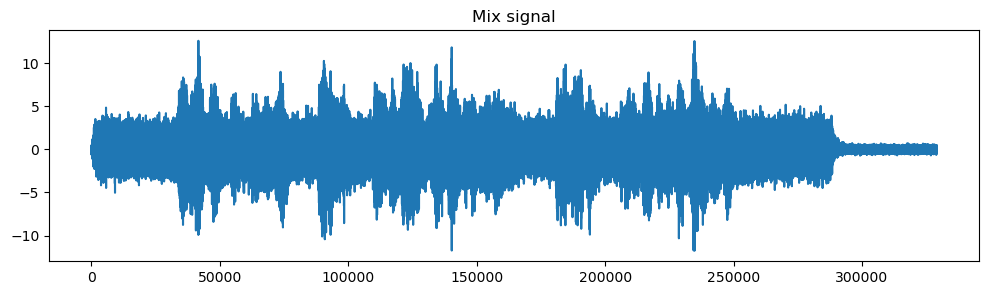

In [40]:
premix = room.simulate(return_premix=True)
mix = room.mic_array.signals

# add tiny noise to the mix
noise = np.random.randn(*mix.shape)
noise = noise / np.std(noise)
noise = noise * np.std(mix) / 10**(SNR/20)
mix = mix + noise

mix_stft = analysis(mix.T)

print("Mix shape: ", mix.shape)
print("Mix STFT shape: ", mix_stft.shape)

plt.figure(figsize=(12, 3))
plt.plot(mix[0])
plt.title("Mix signal")
plt.show()

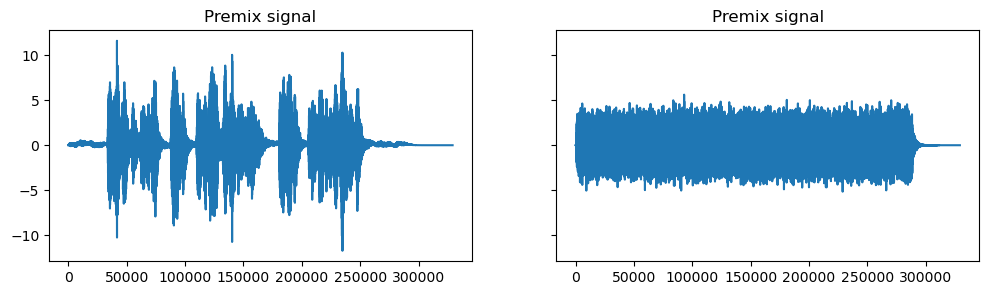

Premix shape:  (2, 24, 329120)
Premix STFT shape:  (2, 643, 513, 24)


In [41]:
premix.shape

fig, ax = plt.subplots(1, 2, figsize=(12, 3), sharex=True, sharey=True)
ax[0].plot(premix[0,0,:])
ax[0].set_title("Premix signal")
ax[1].plot(premix[1,0,:])
ax[1].set_title("Premix signal")
plt.show()

premix_stft = np.stack(
    [analysis(premix[0,:,:].T), 
        analysis(premix[1,:,:].T)
], axis=0)

print("Premix shape: ", premix.shape)
print("Premix STFT shape: ", premix_stft.shape)

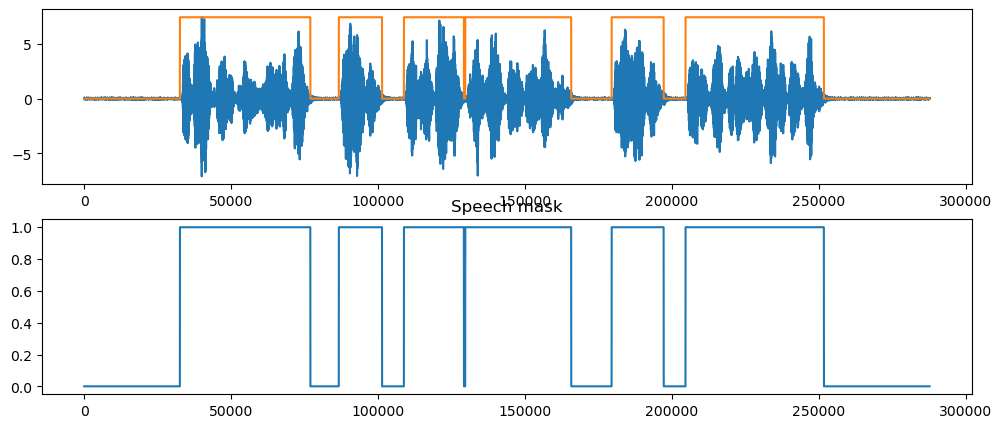

In [42]:
# Compute oracle VAD mask
vad_snd = np.abs(speech_ref) > 0.1*np.max(np.abs(speech_ref))

vad_guard = VAD_GUARD
vad_guarded = vad_snd.copy()
if vad_guard is not None:
    for i, v in enumerate(vad_snd):
        if np.any(vad_snd[i - vad_guard : i + vad_guard]):
            vad_guarded[i] = True
speech_mask = vad_guarded.copy()

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(speech_ref)
plt.plot(speech_mask * np.max(speech_ref))
plt.subplot(2, 1, 2)
plt.plot(speech_mask)
plt.title("Speech mask")
plt.show()

## Compute the RIR

In [43]:
rirs = room.rir
# make rir in a matrix
L = max([max([len(rir) for rir in rir_i]) for rir_i in rirs])
L = max(L, nfft)
rir_matrix = np.zeros((L, len(rirs), len(rirs[0])))
for i, rir_i in enumerate(rirs):
    for j, rir_ij in enumerate(rir_i):
        rir_matrix[:len(rir_ij), i, j] = rir_ij
rirs = rir_matrix # nSamples, nSrc, nChan
print(rirs.shape)

X_atfs = np.stack([analysis(rirs[:,:,0]), analysis(rirs[:,:,1])], axis=0)
X_atfs.shape

(41461, 24, 2)


(2, 81, 513, 24)

## Reference metrics

In [44]:
ref_mic = 0
ref = np.vstack([speech_ref, noise_ref])

L = min(mix.shape[1], speech_ref.shape[0])
ref = ref[:, :L]
mix = mix[:, :L]

print("Reference shape: ", ref.shape)
print("Mix shape: ", mix.shape)

metric = bss_eval_images(
    ref[:, :, None], 
    np.stack([mix[ref_mic,:, None]]*2, axis=0)
)

SDR_in = metric[0][0]
SIR_in = metric[2][0]
print('SDR_in', SDR_in)
print('SIR_in', SIR_in)

results_dict_image['SDR_in'] = SDR_in
results_dict_image['SIR_in'] = SIR_in
results_dict_doa['SDR_in'] = SDR_in
results_dict_doa['SIR_in'] = SIR_in

Reference shape:  (2, 287659)
Mix shape:  (24, 287659)
SDR_in -6.743508089398827
SIR_in 2.296303765738539


## Beamforming

In [45]:
X_mix = analysis(mix.T) # [T x F x M]
oracle_mask_speech = analysis(np.ones_like(mix.T) * vad_guarded[:, None])
X_speech = analysis(mix.T * vad_guarded[:, None])
X_noise = analysis(mix.T * (1 - vad_guarded[:, None]))
oracle_mask_speech = oracle_mask_speech
oracle_mask_noise = 1 - oracle_mask_speech
oracle_mask = oracle_mask_noise
print('X_speech', X_speech.shape)
print('X_noise', X_noise.shape)
print('X_mix', X_mix.shape)

nTime, nFreq, nChan = X_mix.shape

X_speech (562, 513, 24)
X_noise (562, 513, 24)
X_mix (562, 513, 24)


In [46]:
# covariance matrices from noisy signal
Rx = np.einsum("i...j,i...k->...jk", X_mix, np.conj(X_mix)) / X_mix.shape[0]
Rs = np.einsum("i...j,i...k->...jk", X_speech, np.conj(X_speech)) / X_speech.shape[0]
Rsh = np.einsum("i...j,i...k->...jk", X_atfs[0], np.conj(X_atfs[0])) / X_atfs[0].shape[0]
Rn = np.einsum("i...j,i...k->...jk", X_noise, np.conj(X_noise)) / X_noise.shape[0]
Rnh = np.einsum("i...j,i...k->...jk", X_atfs[1], np.conj(X_atfs[1])) / X_atfs[1].shape[0]
Rn += 1e-7 * np.eye(Rn.shape[1]) * np.trace(Rn) / Rn.shape[-1]
eI = 1e-5 * np.trace(Rx) *  np.stack([np.eye(nChan) for _ in range(nFreq)], axis=0) / nChan

assert Rn.shape == (nFreq, nChan, nChan)
assert Rx.shape == Rs.shape == Rn.shape, f'Rx : {Rx.shape}, Rs : {Rs.shape}, Rn : {Rn.shape}'
print('Rx', Rx.shape)
print('Rs', Rs.shape)
print('Rsh', Rsh.shape)
print('Rn', Rn.shape)
print('Rnh', Rnh.shape)
print('eI', eI.shape)

Rx (513, 24, 24)
Rs (513, 24, 24)
Rsh (513, 24, 24)
Rn (513, 24, 24)
Rnh (513, 24, 24)
eI (513, 24, 24)


In [ ]:
if bf_criterion == 'maxsinr':
    Rnum = Rx
    Rden = Rn
    w = max_sinr_weights(Rnum[1:], Rden[1:])
    # Post processing of the weights
    nw = np.linalg.norm(w, axis=1)
    w[nw > 1e-10, :] /= nw[nw > 1e-10, None]
    w = np.concatenate([np.ones((1, nChan)), w], axis=0)
    # normalize with respect to input signal (see Warsitz and Haeb-Umbach, 2007)
    z = []
    for i in range(nChan):
        z.append(compute_gain(w, X_speech, X_speech[...,i]))
    normalization_factor = np.stack(z, -1)
    w_r = np.einsum('fi,fr->fir', w, normalization_factor)
    
elif bf_criterion == 'ds':
    w_r = []
    for i in range(nChan):
        w = delay_and_sum_weights(room.sources[0].position[:,None], room.mic_array.R, room.c, freqs, None)  
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
    
elif bf_criterion == 'mvdr_iso':
    mic_pos = room.mic_array.R # [3 x I]
    ell_ii = np.linalg.norm(mic_pos[:,None,:] - mic_pos[:,:,None], axis=0) # [I x I]
    Gamma = np.sinc(2 * np.pi * freqs[:,None,None] * ell_ii[None] / room.c) # [F x I x I]
    w_r = []
    for i in range(nChan):
        w = mvdr_weights(room.sources[0].position[:,None], room.mic_array.R, room.c, freqs[1:], Gamma[1:], i, True)
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
  
elif bf_criterion == 'mvdr':
    w_r = []
    for i in range(nChan):
        w = mvdr_weights(room.sources[0].position[:,None], room.mic_array.R, room.c, freqs[1:], Rn[1:], i, True)
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
    
elif bf_criterion == 'lcmv':
    w_r = []
    for i in range(nChan):
        w = lcmv_weights(
            room.sources[0].position[:,None], # target
            room.sources[1].position[:,None], # interf
            room.mic_array.R, room.c, freqs[1:], Rn[1:], i, True)
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
    
elif bf_criterion == 'rake':
    w_r = []
    for i in range(nChan):
        w = rake_weights(
            source_echoes[0]["images"][:,:5], 
            room.mic_array.R, room.c, freqs[1:], Rn[1:], i, 0)
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
    
    
elif bf_criterion == 'matched':
    w_r = []
    for i in range(nChan):
        w = souden_weights(Rn=Rn[1:], Rs=Rsh[1:], ref_mic_idx=i)
        w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
        w_r.append(w)
    w_r = np.stack(w_r, axis=-1)
    
else:
    raise ValueError(f"Unknown beamforming criterion {bf_criterion}")


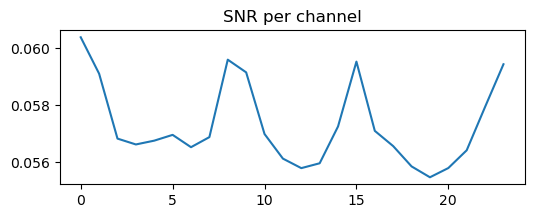

[0.06037501 0.05909971 0.05682509 0.05662005 0.05675347 0.05695605
 0.05652432 0.05687694 0.05959018 0.059146   0.05698609 0.05612415
 0.05579063 0.05596091 0.05725118 0.05952202 0.05709638 0.05656218
 0.05585107 0.05547008 0.0557933  0.05641606 0.05793604 0.05943046]
Best reference microphone is 0


In [99]:
# find the best reference microphone
snr_per_chan = np.einsum('fir,fij,fjr->r', w_r.conj(), Rs, w_r).real / np.einsum('fir,fij,fjr->r', w_r.conj(), Rn, w_r).real
snr_per_chan = snr_per_chan / nFreq

plt.figure(figsize=(6, 2))
plt.plot(snr_per_chan)
plt.title("SNR per channel")
plt.show()

print(snr_per_chan)

ref_mic_idx = np.argmax(snr_per_chan)
print(f"Best reference microphone is {ref_mic_idx}")
w = w_r[:,:,ref_mic_idx]
bf_weights = w_r[:,:,ref_mic_idx]

results_dict_doa['ref_mic_idx'] = ref_mic_idx
results_dict_image['ref_mic_idx'] = ref_mic_idx

Apply beamformer


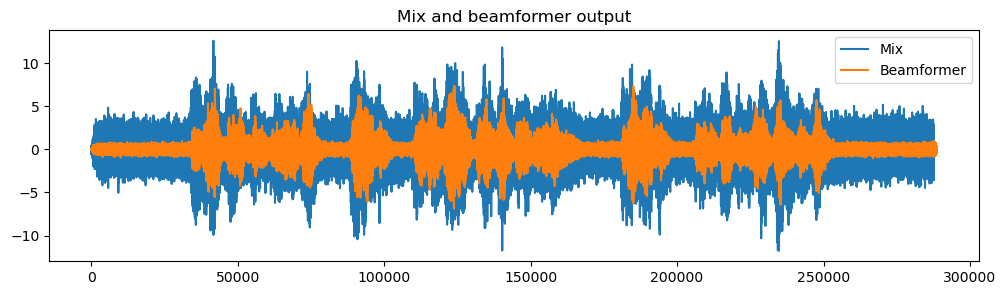

In [100]:
print("Apply beamformer")

# 2D beamformer
mic_array = pra.Beamformer(
    mics_positions.T[:2], fs=fs_snd, N=nfft, hop=nfft, zpb=nfft # it s in 2D so we can plot the response
)
mic_array.signals = mix
mic_array.weights = w.T

out = mic_array.process()
bf_out = out.copy()

plt.figure(figsize=(12,3))
plt.plot(mix[ref_mic], label="Mix")
plt.plot(out, label="Beamformer")
plt.legend()
plt.title("Mix and beamformer output")
plt.show()

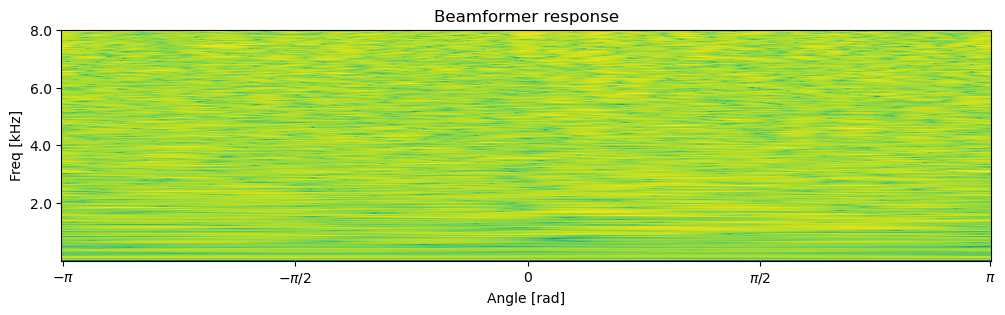

In [101]:
plt.figure(figsize=(12, 3))
mic_array.plot_beam_response()
plt.title("Beamformer response")
plt.show()

In [102]:
# Signal alignment step
ref = np.vstack([speech_ref, noise_ref])
# Not sure why the delay is sometimes negative here... Need to check more
delay = np.abs(int(pra.tdoa(out, speech_ref.astype(float), phat=True)))
if delay > 0:
    out_trunc = out[delay : delay + ref.shape[1]]
    noise_eval = mix.T[: ref.shape[1], ref_mic_idx] - out_trunc
else:
    out_trunc = np.concatenate((np.zeros(-delay), out[: ref.shape[1] + delay]))
    noise_eval = mix.T[: ref.shape[1], ref_mic_idx] - out_trunc
sig_eval = np.vstack([out_trunc, noise_eval])

# We use the BSS eval toolbox
metric = bss_eval_images(ref[:, :, None], sig_eval[:, :, None])

# we are only interested in SDR and SIR for the speech source
SDR_out = metric[0][0]
SIR_out = metric[2][0]

print(f'Metric: SDR_out {SDR_out:.2f}  SIR_out {SIR_out:.2f}')
iSDR = SDR_out - SDR_in
iSIR = SIR_out - SIR_in
print(f'Improvement: iSDR {iSDR:.2f} iSIR {iSIR:.2f}')

results_dict_image['SDR_out'] = SDR_out
results_dict_image['SIR_out'] = SIR_out
results_dict_image['iSDR'] = iSDR
results_dict_image['iSIR'] = iSIR
results_dict_doa['SDR_out'] = SDR_out
results_dict_doa['SIR_out'] = SIR_out
results_dict_doa['iSDR'] = iSDR
results_dict_doa['iSIR'] = iSIR

Metric: SDR_out -1.62  SIR_out 17.69
Improvement: iSDR 5.13 iSIR 15.39


## Beamform each image

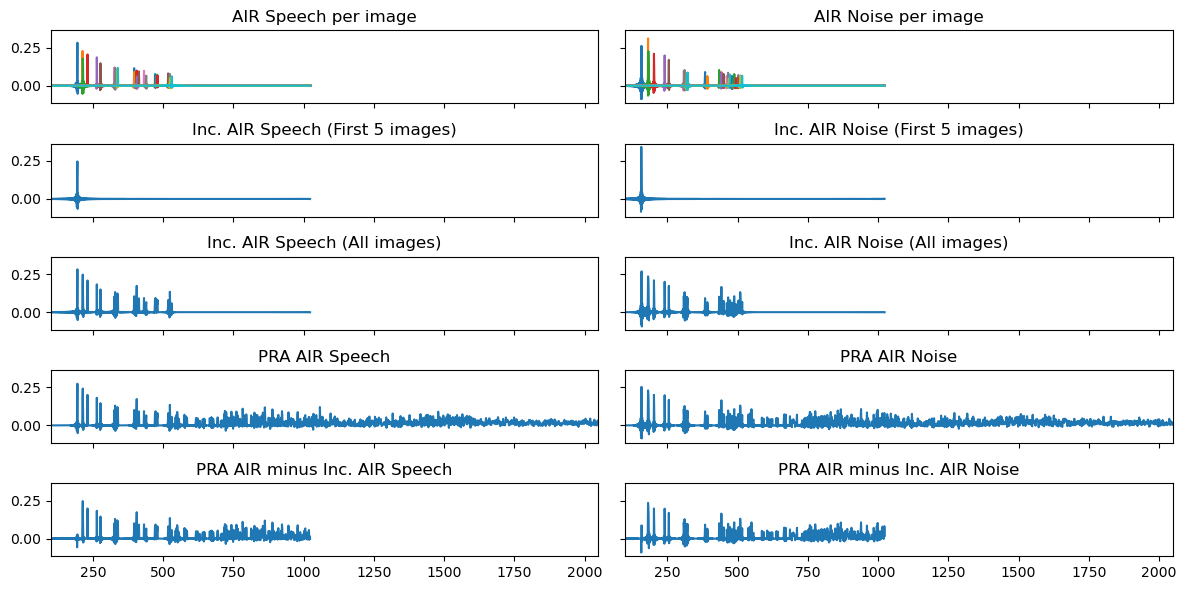

In [103]:
# plot the partial RIRs for each image
fig, axarr = plt.subplots(5, 2, figsize=(12, 6), sharex=True, sharey=True)

for i in range(atfs.shape[1]):
    atf = source_echoes[0]["atfs_fji"][:,i,0]
    air = np.fft.irfft(atf, nfft)
    axarr[0,0].plot(air)
    
    atf = source_echoes[1]["atfs_fji"][:,i,0]
    air = np.fft.irfft(atf, nfft)
    axarr[0,1].plot(air)
axarr[0,0].set_title("AIR Speech per image")
axarr[0,1].set_title("AIR Noise per image") 

atf = source_echoes[0]["incremental_atf_fji"][:,0,3]
air1 = np.fft.irfft(atf, nfft)
axarr[1,0].plot(air1)
axarr[1,0].set_title("Inc. AIR Speech (First 5 images)")

atf = source_echoes[1]["incremental_atf_fji"][:,0,3]
air2 = np.fft.irfft(atf, nfft)
axarr[1,1].plot(air2)
axarr[1,1].set_title("Inc. AIR Noise (First 5 images)")
    
atf = source_echoes[0]["incremental_atf_fji"][:,-1,0]
air = np.fft.irfft(atf, nfft)
axarr[2,0].plot(air)
axarr[2,0].set_title("Inc. AIR Speech (All images)")

atf = source_echoes[1]["incremental_atf_fji"][:,-1,0]
air = np.fft.irfft(atf, nfft)
axarr[2,1].plot(air)
axarr[2,1].set_title("Inc. AIR Noise (All images)")

axarr[3,0].plot(rirs[:,0,0])
axarr[3,0].set_title("PRA AIR Speech")
axarr[3,1].plot(rirs[:,0,1])
axarr[3,1].set_title("PRA AIR Noise")

L = min(len(air1), rirs.shape[0]-40)

axarr[4,0].plot(rirs[:L,0,0] - air1[:L])
axarr[4,0].set_title("PRA AIR minus Inc. AIR Speech")
axarr[4,1].plot(rirs[:L,0,1] - air2[:L])
axarr[4,1].set_title("PRA AIR minus Inc. AIR Noise")


plt.xlim([100, 2048])
plt.tight_layout()
plt.show()

In [104]:
from scipy.signal import fftconvolve


engine_1chan = pra.transform.stft.STFT(
    nfft, nfft // 2, pra.hann(nfft), channels=1
)

def analysis_1chan(x):
    engine_1chan.analysis(x)
    return engine_1chan.X

def synthesis_1chan(X):
    engine_1chan.X = X
    return engine_1chan.synthesis()

# def stacked_systhesis(x):
#     return np.stack([synthesis(x[:,:,k,:]) for k in range(x.shape[2])], axis=1)

# def stacked_systhesis_1chan(x):
#     return np.stack([synthesis_1chan(x[:,:,k]) for k in range(x.shape[2])], axis=1)

mic_images = []
inc_mic_images = []
bf_mic_images = []
bf_inc_mic_images = []

S_ref = analysis_1chan(speech_ref.T)
N_ref = analysis_1chan(noise_ref.T)

sources_freq_signal = [S_ref, N_ref]
sources = [speech_ref, noise_ref]

nFreq, nImg, nChan = source_echoes[0]['atfs_fji'].shape

for j in range(len(room.sources)):
    
    name = source_echoes[j]['name']
    atfs_fki = source_echoes[j]['atfs_fji']
    inc_atf_fki = source_echoes[j]['incremental_atf_fji']
    
    airs = np.fft.irfft(atfs_fki, nfft, axis=0)
    inc_airs = np.fft.irfft(inc_atf_fki, nfft, axis=0)
    
    # go in the time domain
    sig = sources[j]
    mic_image = []
    inc_mic_image = []

    L = airs.shape[0] + sig.shape[0] - 1
    
    mic_image = np.zeros((L, nImg, nChan))
    inc_mic_image = np.zeros((L, nImg, nChan))

    for k in range(nImg):
        for i in np.arange(nChan):
            conv = fftconvolve(airs[:,k,i], sig)
            mic_image[:len(conv),k,i] = conv
            conv = fftconvolve(inc_airs[:,k,i], sig)
            inc_mic_image[:len(conv),k,i] = conv
    
    
    mic_images.append(mic_image)
    inc_mic_images.append(inc_mic_image)
    
    bf_images = []
    bf_inc_images = []
    for k in range(nImg):
        mic_array.signals = mic_images[j][:,k,:].T
        mic_array.weights = bf_weights.T
        bf_images.append(mic_array.process())
        
        mic_array.signals = inc_mic_images[j][:,k,:].T
        mic_array.weights = bf_weights.T
        bf_inc_images.append(mic_array.process())
        
    bf_mic_images.append(np.stack(bf_images, axis=1))
    bf_inc_mic_images.append(np.stack(bf_inc_images, axis=1))


mic_images = np.stack(mic_images, axis=0)                 # [nSrc x T x nDoas x nChan]
inc_mic_images = np.stack(inc_mic_images, axis=0)         # [nSrc x T x nDoas x nChan]
bf_mic_images = np.stack(bf_mic_images, axis=0)           # [nSrc x T x nDoas]
bf_inc_mic_images = np.stack(bf_inc_mic_images, axis=0)   # [nSrc x T x nDoas]

print('mic_images', mic_images.shape)
print('inc_mic_images', inc_mic_images.shape)
print('bf_mic_images', bf_mic_images.shape)
print('bf_inc_mic_images', bf_inc_mic_images.shape)

mic_images (2, 288682, 30, 24)
inc_mic_images (2, 288682, 30, 24)
bf_mic_images (2, 289705, 30)
bf_inc_mic_images (2, 289705, 30)


In [105]:
assert np.allclose(mic_images[0,:,0,0], inc_mic_images[0,:,0,0])

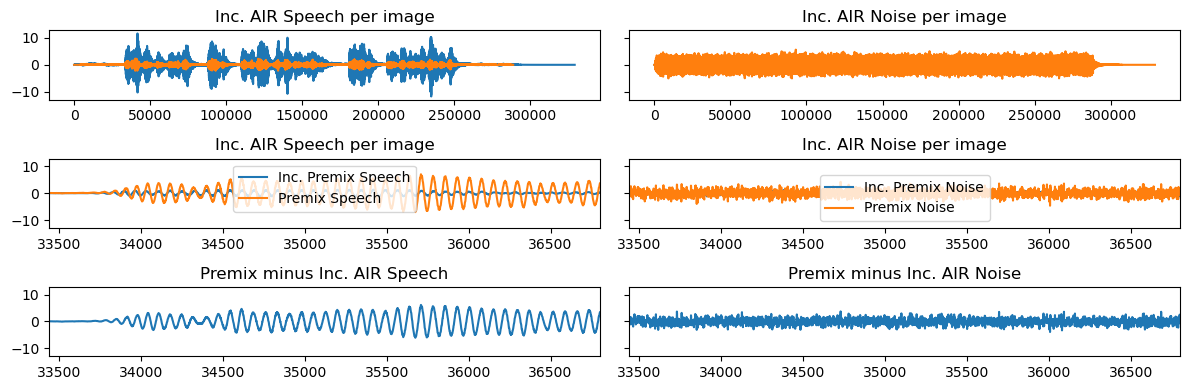

In [106]:
# plot partial images
fig, axarr = plt.subplots(3, 2, figsize=(12, 4), sharey=True)

axarr[0,0].plot(premix[0,ref_mic,:])
axarr[0,0].plot(inc_mic_images[0,:,0,ref_mic])
axarr[0,1].plot(inc_mic_images[1,:,0,ref_mic])
axarr[0,1].plot(premix[1,ref_mic,:])
axarr[0,0].set_title("Inc. AIR Speech per image")
axarr[0,1].set_title("Inc. AIR Noise per image")

# premix_stft
axarr[1,0].plot(mic_images[0,:,0,ref_mic], label="Inc. Premix Speech")
axarr[1,0].plot(premix[0,ref_mic,:], label="Premix Speech")
axarr[1,1].plot(mic_images[1,:,0,ref_mic], label="Inc. Premix Noise")
axarr[1,1].plot(premix[1,ref_mic,:], label="Premix Noise")
axarr[1,0].legend()
axarr[1,1].legend()
axarr[1,0].set_title("Inc. AIR Speech per image")
axarr[1,1].set_title("Inc. AIR Noise per image")
axarr[1,0].set_xlim([2.09*fs, 2.3*fs])
axarr[1,1].set_xlim([2.09*fs, 2.3*fs])

# differences
L = 3*fs
axarr[2,0].plot(premix[0,ref_mic,:L] - mic_images[0,:L,0,ref_mic])
axarr[2,1].plot(premix[1,ref_mic,:L] - mic_images[1,:L,0,ref_mic])
axarr[2,0].set_title("Premix minus Inc. AIR Speech")
axarr[2,1].set_title("Premix minus Inc. AIR Noise")
axarr[2,0].set_xlim([2.09*fs, 2.3*fs])
axarr[2,1].set_xlim([2.09*fs, 2.3*fs])

plt.tight_layout()

full_image (2, 329119, 24)
bf_full_image (2, 330142)


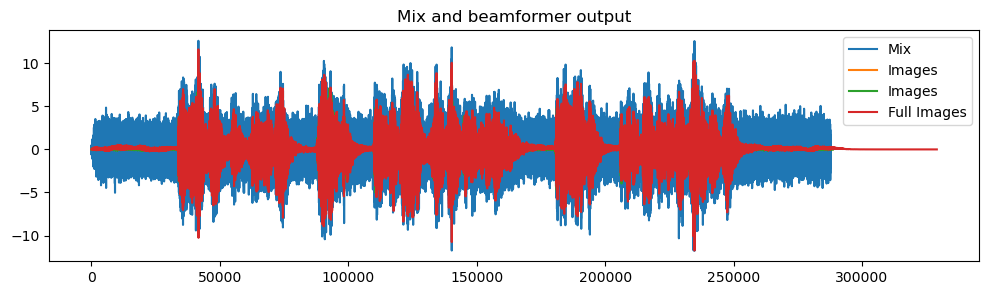

In [107]:
# Get the full image with RIR and apply beamforming
L = rirs.shape[0] + sig.shape[0] - 1
full_images = np.zeros((2, L, nChan))
bf_full_images = np.zeros((2, L + nfft - 1))


for j in range(len(room.sources)):
    for i in range(nChan):
        conv = fftconvolve(rirs[:,i,j].T, sources[j])
        full_images[j, : len(conv), i] = conv

    mic_array.signals = full_images[0].T
    mic_array.weights = bf_weights.T
    out = mic_array.process()
    bf_full_images[j, :len(out)] = out

print('full_image', full_images.shape)
print('bf_full_image', bf_full_images.shape)

plt.figure(figsize=(12, 3))

plt.plot(mix[ref_mic], label="Mix")
plt.plot(mic_images[0,:,0,ref_mic], label="Images")
plt.plot(inc_mic_images[0,:,-1,ref_mic], label="Images")
plt.plot(full_images[0,:,ref_mic], label="Full Images")
plt.legend()
plt.title("Mix and beamformer output")
plt.show()

# plt.plot(bf_out)
# plt.plot(bf_full_images[0])
# plt.title("Beamformed full image")
# plt.show()

In [108]:
# Apply beamforming to the noise
mic_array.signals = noise
mic_array.weights = bf_weights.T
bf_noise = mic_array.process()

### SIR for each image

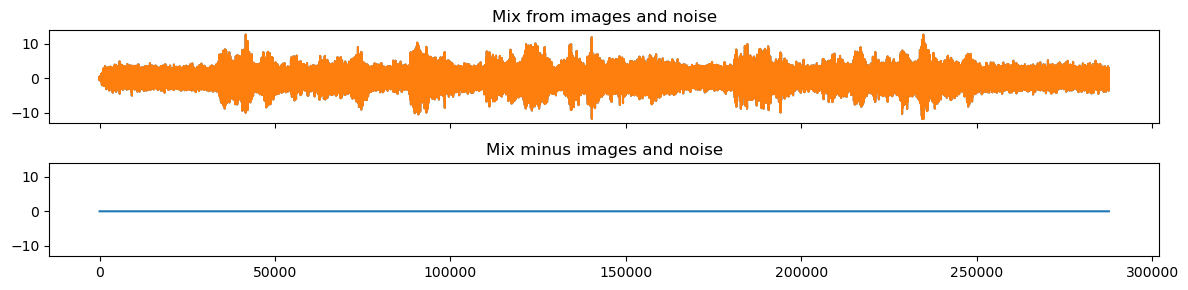

In [109]:
L = min(mix.shape[1], full_images.shape[1], noise.shape[1])

# first we need to check that the images correctly provide the mix signal
mix_from_images = full_images[:, : L, ref_mic].sum(0) + noise[ref_mic,: L]
mix_minus_contrib = mix[ref_mic,: L] - mix_from_images

fig, axarr = plt.subplots(2, 1, figsize=(12, 3), sharex=True, sharey=True)
axarr[0].plot(mix_from_images)
axarr[0].plot(mix[ref_mic,:L])
axarr[0].set_title("Mix from images and noise")
axarr[1].plot(mix_minus_contrib)
axarr[1].set_title("Mix minus images and noise")
# plt.xlim([2.2*fs, 2.5*fs])
plt.tight_layout()
plt.show()

## Metrics
### OIR

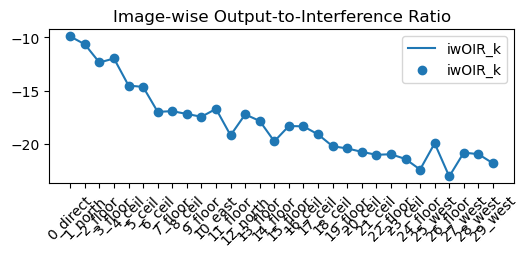

In [110]:
# Compute Image-wise Output-to-Interference Ratio for each image
iwOIR_k_out = []
for k in range(nImg):
    other_bf_images = bf_mic_images[j].sum(-1) - bf_mic_images[j,:,k]
    bf_interf = bf_mic_images[1].sum(-1)
    L = min(other_bf_images.shape[0], bf_interf.shape[0], bf_noise.shape[0])
    all_rest = other_bf_images[: L] + bf_noise[: L] + bf_interf[: L]
    
    noise_power_out = np.std(all_rest)**2
    signal_power_out = np.std(bf_mic_images[0,:L,k])**2
    
    ratio_dB = 10 * np.log10(signal_power_out / noise_power_out)
    
    iwOIR_k_out.append(ratio_dB)
    
iwOIR_k_out = np.array(iwOIR_k_out)

images_names = source_echoes[0]["images_names"][:mic_images.shape[2]]
plt.figure(figsize=(6, 2))
plt.plot(images_names, iwOIR_k_out, label="iwOIR_k")
plt.scatter(images_names, iwOIR_k_out, label="iwOIR_k")
plt.legend()
plt.title("Image-wise Output-to-Interference Ratio")
plt.xticks(rotation=45)
plt.show()

results_dict_image['image_id'] = np.arange(nImg).tolist()
results_dict_image['image_name'] = images_names
results_dict_image['iwOIR_k'] = iwOIR_k_out.tolist()

### Image Preservation

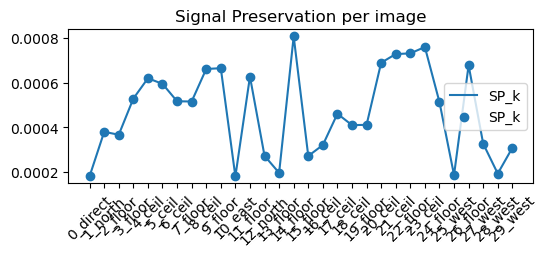

In [64]:
# Signal Preservation (SP): How much of image si​ is preserved with respect to the original image
IP_k_out = []
for k in range(mic_images.shape[2]):
    
    bf_out_power = np.std(bf_mic_images[0,:,k])**2
    ref_sig_power = np.std(mic_images[0,:, k])**2
    
    IP_k_out.append(bf_out_power / ref_sig_power)
    
IP_k_out = np.array(IP_k_out)


images_names = source_echoes[0]["images_names"][:mic_images.shape[2]]
plt.figure(figsize=(6, 2))
plt.plot(images_names, IP_k_out, label="SP_k")
plt.scatter(images_names, IP_k_out, label="SP_k")
plt.legend()
plt.title("Signal Preservation per image")
plt.xticks(rotation=45)
plt.show()

results_dict_image['IP_k'] = IP_k_out.tolist()

### Signal Preservation 

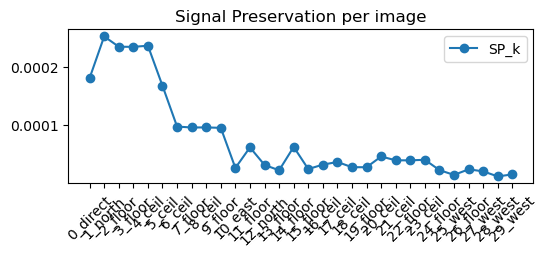

In [65]:
# Signal Preservation (SP): How much of image si​ is preserved with respect to the original image
SP_k_out = []
for k in range(mic_images.shape[2]):
    
    bf_out_power = np.std(bf_mic_images[0,:,k])**2
    ref_sig_power = np.std(mic_images[0,:, 0])**2
    
    SP_k_out.append(bf_out_power / ref_sig_power)
    
SP_k_out = np.array(SP_k_out)


images_names = source_echoes[0]["images_names"][:mic_images.shape[2]]
plt.figure(figsize=(6, 2))
plt.plot(images_names, SP_k_out, label="SP_k", marker='o')
plt.legend()
plt.title("Signal Preservation per image")
plt.xticks(rotation=45)
plt.show()

results_dict_image['SP_k'] = SP_k_out.tolist()

### SNR_k

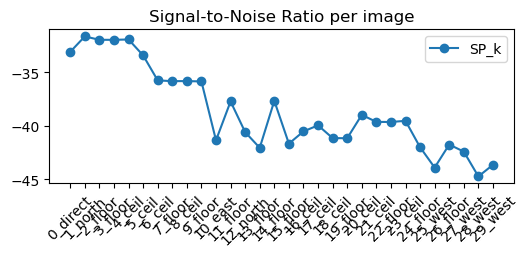

In [66]:
# SNR with respect to residual noise/interference
SNR_k_out = []

for k in range(mic_images.shape[2]):
    
    L = min(bf_noise.shape[0], bf_mic_images[0,:,k].shape[0], bf_interf.shape[0])
    bf_distortion = bf_noise[: L] + bf_interf[: L]
    
    bf_distortion_power = np.std(bf_distortion)**2
    bf_out_power = np.std(bf_mic_images[0,:L,k])**2
    
    snr_ = 10 * np.log10(bf_out_power / bf_distortion_power)
    
    SNR_k_out.append(snr_)
    
SNR_k_out = np.array(SNR_k_out)

results_dict_image['SNR_k'] = SNR_k_out.tolist()

images_names = source_echoes[0]["images_names"][:mic_images.shape[2]]
plt.figure(figsize=(6, 2))
plt.plot(images_names, SNR_k_out, label="SP_k", marker='o')
plt.legend()
plt.title("Signal-to-Noise Ratio per image")
plt.xticks(rotation=45)
plt.show()

### Rakeness

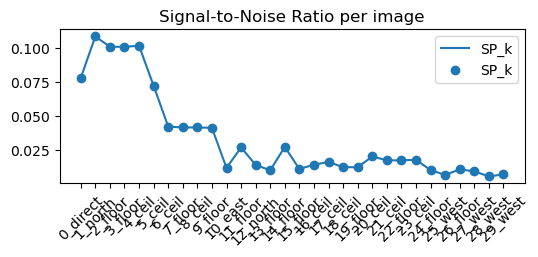

In [67]:
# SNR with respect to residual noise/interference
Rakeness_k_out = []
for k in range(mic_images.shape[2]):
    L = min(bf_mic_images[0,:,k].shape[0], bf_full_images.shape[1])
    image_power = np.std(bf_mic_images[0,:L,k])**2
    # all_images_power_ = np.std(bf_full_images[0,:L])**2
    all_images_power = np.sum(np.std(bf_mic_images[0,:L,:], axis=0)**2)
    Rakeness_k_out.append(image_power / all_images_power)
    
Rakeness_k_out = np.array(Rakeness_k_out)

results_dict_image['Rakeness_k'] = Rakeness_k_out.tolist()

images_names = source_echoes[0]["images_names"][:mic_images.shape[2]]
plt.figure(figsize=(6, 2))
plt.plot(images_names, Rakeness_k_out, label="SP_k")
plt.scatter(images_names, Rakeness_k_out, label="SP_k")
plt.legend()
plt.title("Signal-to-Noise Ratio per image")
plt.xticks(rotation=45)
plt.show()

### BF gain

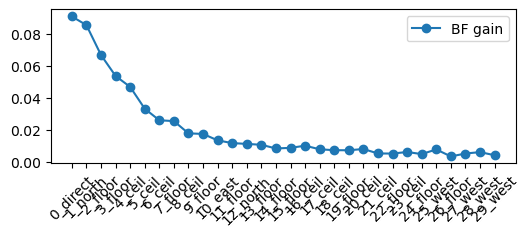

In [120]:
# Correlation per image
images_atfs = source_echoes[0]["atfs_fji"]
nFreq, nImg, nChan = images_atfs.shape

bf_gain = np.abs(np.einsum('fi,fji->fj', bf_weights.conj(), images_atfs))**2

# plt.figure(figsize=(12,6))
# plt.imshow(bf_gain, aspect='auto', origin='lower')
# plt.colorbar()
# plt.show()

bf_gain_pooled = np.mean(bf_gain, axis=0)
plt.figure(figsize=(6, 2))
plt.plot(images_names, bf_gain_pooled, label="BF gain", marker='o')
# rotate the x axis
plt.xticks(rotation=45)
plt.legend()
plt.show()

results_dict_image['bf_gain_k'] = bf_gain_pooled.tolist()

### Correlation

/var/folders/6j/jjy0khhn7n57n5dmw92shzg80000gn/T/ipykernel_98218/1711956415.py:15: RuntimeWarning: invalid value encountered in divide
  corr_with_bf /= np.linalg.norm(target, axis=-1)[:,None] * np.linalg.norm(images_atfs, axis=-1)


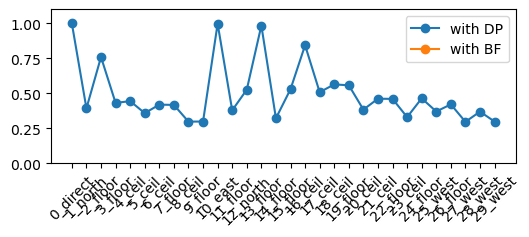

In [ ]:
# Correlation per image
images_atfs = source_echoes[0]["atfs_fji"]
nFreq, nImg, nChan = images_atfs.shape

target = images_atfs[:,0,:]
corr_with_dp = np.abs(np.einsum('fi,fji->fj', target.conj(), images_atfs))
corr_with_dp /= np.linalg.norm(target, axis=-1)[:,None] * np.linalg.norm(images_atfs, axis=-1)
corr_pooled_with_dp = np.mean(corr_with_dp, axis=0)

target = bf_weights
corr_with_bf = np.abs(np.einsum('fi,fji->fj', target.conj(), images_atfs))
corr_with_bf /= np.linalg.norm(target, axis=-1)[:,None] * np.linalg.norm(images_atfs, axis=-1)
corr_pooled_with_bf = np.mean(corr_with_bf, axis=0)

plt.figure(figsize=(6, 2))
plt.plot(images_names, corr_pooled_with_dp, label="with DP", marker='o')
plt.plot(images_names, corr_pooled_with_bf, label="with BF", marker='o')
# rotate the x axis
plt.ylim([0, 1.1])
plt.xticks(rotation=45)
plt.legend()
plt.show()

results_dict_image['corr_with_bf_k'] = corr_pooled_with_bf.tolist()
results_dict_image['corr_with_dp_k'] = corr_pooled_with_dp.tolist()

### DI

In [70]:
# create a grid of DOAs
src_pos = room.sources[0].position
mic_pos = room.mic_array.R
arr_pos = room.mic_array.center

print("Source position: ", src_pos)
print("Microphone position: ", mic_pos)
print("Array position: ", arr_pos)

src_arr_dist = np.linalg.norm(src_pos - arr_pos)

print("Source to array distance: ", src_arr_dist)

Source position:  [6.778 6.656 0.85 ]
Microphone position:  [[3.46339746 3.46339746 3.46339746 3.46339746 3.46339746 3.46339746
  3.46339746 3.46339746 3.67990381 3.64526279 3.61062178 3.59676537
  3.58983717 3.57598076 3.54133975 3.50669873 3.50669873 3.54133975
  3.57598076 3.58983717 3.59676537 3.61062178 3.64526279 3.67990381]
 [6.511      6.551      6.591      6.607      6.615      6.631
  6.671      6.711      6.586      6.566      6.546      6.538
  6.534      6.526      6.506      6.486      6.736      6.716
  6.696      6.688      6.684      6.676      6.656      6.636     ]
 [0.875      0.875      0.875      0.875      0.875      0.875
  0.875      0.875      0.875      0.875      0.875      0.875
  0.875      0.875      0.875      0.875      0.875      0.875
  0.875      0.875      0.875      0.875      0.875      0.875     ]]
Array position:  [[3.55 ]
 [6.611]
 [0.875]]
Source to array distance:  11.35087001070843


(3, 360)


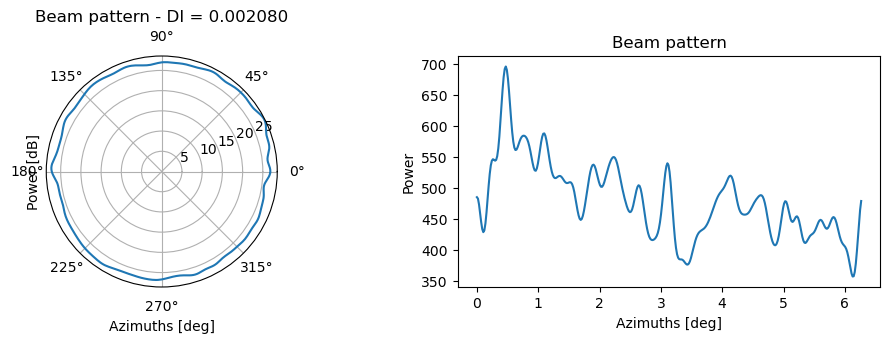

In [111]:
nDoas = 360
grid_circ = pra.doa.grid.GridCircle(n_points=360)
cart_pts_circ = grid_circ.cartesian
cart_pts_circ *= src_arr_dist
cart_pts_circ += arr_pos
azimuths = grid_circ.azimuth
print(cart_pts_circ.shape)

beampatter_circ = np.zeros((nDoas, nFreq))
for i in range(nDoas):
    steering_vector = compute_steering_vector(cart_pts_circ[:,[i]], mic_pos, room.c, freqs, ref_mic_idx=ref_mic_idx, mode="near")
    beampatter_circ[i,:] = np.abs(np.einsum('fi,fji->fj', bf_weights.conj(), steering_vector)[:,0])**2

# compute directivity index
DI = 1 / beampatter_circ.sum(-1).mean()

plt.figure(figsize=(12, 3))
ax = plt.subplot(121, polar=True)
ax.plot(azimuths, 10 * np.log10(beampatter_circ.sum(-1)))
plt.title(f"Beam pattern - DI = {DI:.6f}")
plt.xlabel("Azimuths [deg]")
plt.ylabel("Power [dB]")
ax = plt.subplot(122)
ax.plot(azimuths, beampatter_circ.sum(-1))
plt.title(f"Beam pattern")
plt.xlabel("Azimuths [deg]")
# shift the x axis by 90 degrees
plt.ylabel("Power")
plt.show()

results_dict_doa['azimuths'] = azimuths.tolist()
results_dict_doa['beampatter_circ'] = beampatter_circ.tolist()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Directivity index:  0.024591203606622893


/Users/chutlhu/miniconda3/envs/maxsinr/lib/python3.9/site-packages/pyroomacoustics/doa/plotters.py:250: UserWarning: The plotly package is required to use this function
  warnings.warn("The plotly package is required to use this function")


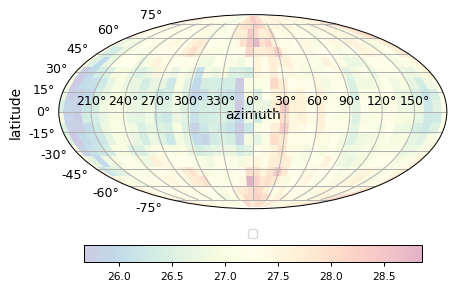

In [112]:
nDoas_sph = 1000
grid_sph = pra.doa.grid.GridSphere(n_points=nDoas_sph)
cart_pts_sph = grid_sph.cartesian
cart_pts_sph *= src_arr_dist
cart_pts_sph += arr_pos
colatitude = grid_sph.colatitude

beampatter_sph = np.zeros((nDoas_sph, nFreq))
for i in range(nDoas_sph):
    steering_vector = compute_steering_vector(cart_pts_sph[:,[i]], mic_pos, room.c, freqs, ref_mic_idx=ref_mic_idx, mode="near")
    beampatter_sph[i,:] = np.abs(np.einsum('fi,fji->fj', bf_weights.conj(), steering_vector)[:,0])**2

# compute directivity index
P = beampatter_sph.sum(-1)
DI_full = np.sum(P * np.sin(colatitude), axis=0) / (4 * np.pi)

DI = np.max(P) / DI_full

print("Directivity index: ", DI)

results_dict_image["DI_svect"] = DI
results_dict_doa["DI_svect"] = DI

grid_sph.set_values(10 * np.log10(P))
grid_sph.plot()
plt.show()

In [113]:
mic_pos = room.mic_array.R
# compute all pair distances
distances = np.linalg.norm(mic_pos[:,:,None] - mic_pos[:,None,:], axis=0)
# compute the isotropic coherence matrix
noise_coherence = np.sinc(2 * freqs[:,None,None] * distances[None] / room.c)
# compute the directivity index
DI = 1 / np.einsum('fi,fij,fj->f', bf_weights.conj(), noise_coherence, bf_weights).real[1:]
print("Directivity index with diffuse noise: ", DI.sum())

results_dict_image["DI_diff"] = DI.sum()
results_dict_doa["DI_diff"] = DI.sum()

Directivity index with diffuse noise:  805.8181280828707


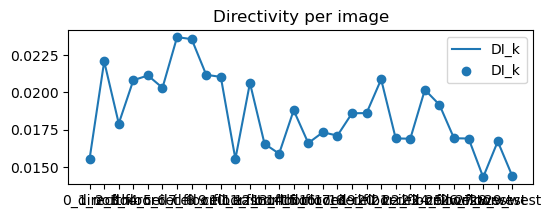

In [114]:
# Directivity per image
DI_per_k = []
for k in range(mic_images.shape[2]):
    atf = source_echoes[0]["atfs_fji"][:,k,:]
    svect = compute_steering_vector(source_echoes[0]['images'][:,[k]], room.mic_array.R, room.c, freqs, ref_mic_idx=None, mode="near", delay_sec=40/fs)
    power_k = np.sum(np.abs(np.einsum('fi,fji->fj', bf_weights.conj(), svect))**2)
    DI_per_k.append(power_k / DI_full)
    
DI_per_k = np.array(DI_per_k)

plt.figure(figsize=(6, 2))
plt.plot(images_names, DI_per_k, label="DI_k")
plt.scatter(images_names, DI_per_k, label="DI_k")
plt.legend()
plt.title("Directivity per image")

results_dict_image['DI_k'] = DI_per_k.tolist()


### Beamwitdh

In [115]:
def longest_true_run(array):
    max_len = 0
    current_len = 0
    for val in array:
        if val:
            current_len += 1
            max_len = max(max_len, current_len)
        else:
            current_len = 0
    return max_len

Peak at 0.00 with beamwidth 720 degrees
Peak at 0.26 with beamwidth 720 degrees
Peak at 0.47 with beamwidth 720 degrees
Peak at 0.77 with beamwidth 720 degrees
Peak at 1.10 with beamwidth 720 degrees
Peak at 1.34 with beamwidth 720 degrees
Peak at 1.52 with beamwidth 720 degrees
Peak at 1.90 with beamwidth 720 degrees
Peak at 2.23 with beamwidth 720 degrees
Peak at 2.64 with beamwidth 720 degrees
Peak at 3.11 with beamwidth 720 degrees
Peak at 4.14 with beamwidth 720 degrees
Peak at 4.63 with beamwidth 720 degrees
Peak at 5.03 with beamwidth 720 degrees
Peak at 5.22 with beamwidth 720 degrees
Peak at 5.60 with beamwidth 720 degrees
Peak at 5.81 with beamwidth 720 degrees


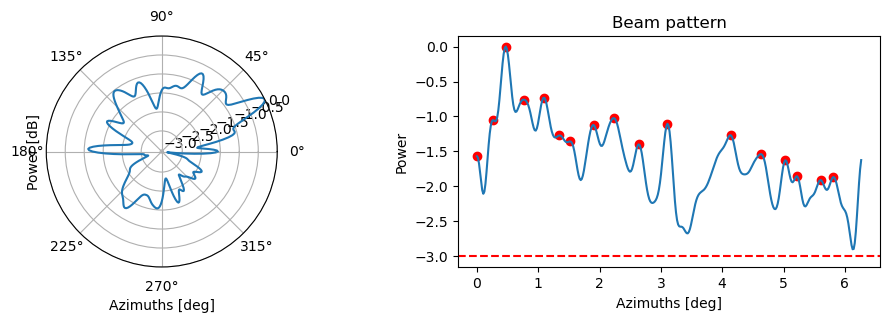

In [116]:
norm_beam_patter = 10 * np.log10(beampatter_circ.sum(-1) / beampatter_circ.sum(-1).max())

# find all the peak that are above 3dB
mod_beam_patter = np.concatenate([norm_beam_patter, norm_beam_patter[:10]])
mod_beam_patter += 3
mod_beam_patter[mod_beam_patter < 0] = 0
peaks_idx = pra.doa.detect_peaks(mod_beam_patter)
peaks_idx = np.unique(np.mod(peaks_idx, len(norm_beam_patter)))

# compute the beamwidth
candidate_reflections_for_doa = np.zeros_like(azimuths)
beamwidths_for_doa = np.zeros_like(azimuths)
for idx in peaks_idx:
    max_val = norm_beam_patter[idx]
    azim_above_m3dB = norm_beam_patter > max_val - 3 # 3dB below the peak
    # take the longest subsequence of True in azim_above_m3dB
    azim_above_m3dB = np.concatenate([azim_above_m3dB, azim_above_m3dB])
    azim_above_m3dB = np.concatenate([azim_above_m3dB, [False]])
    longest_run = longest_true_run(azim_above_m3dB.astype(int))
    print(f"Peak at {azimuths[idx]:.2f} with beamwidth {longest_run} degrees")

    # check wheather the peaks include some reflections
    doa_az = np.rad2deg(azimuths[idx])
    # doa = np.rad2deg(source_echoes[0]['doas'][source_echoes[0]['early_reflection_flag']])
    doa = np.rad2deg(source_echoes[0]['doas'])
    candidate_reflections = np.abs(doa - doa_az) < 1
    
    candidate_reflections_for_doa[idx] = candidate_reflections.sum()
    beamwidths_for_doa[idx] = longest_run
    

### compute the beamwidth
plt.figure(figsize=(12, 3))
ax = plt.subplot(121, polar=True)
ax.plot(azimuths, norm_beam_patter)
plt.xlabel("Azimuths [deg]")
plt.ylabel("Power [dB]")
ax = plt.subplot(122)
ax.plot(azimuths, norm_beam_patter)
ax.axhline(norm_beam_patter.max() - 3, color='r', linestyle='--')
plt.scatter(azimuths[peaks_idx], norm_beam_patter[peaks_idx], color='r')
plt.title(f"Beam pattern")
plt.xlabel("Azimuths [deg]")
# shift the x axis by 90 degrees
plt.ylabel("Power")
plt.show()

results_dict_doa['candidate_reflections_for_doa'] = candidate_reflections_for_doa.tolist()
results_dict_doa['beamwidths_for_doa'] = beamwidths_for_doa.tolist()

### Directivity ratio

Directivity index of MaxISO:  5.8126187536562375


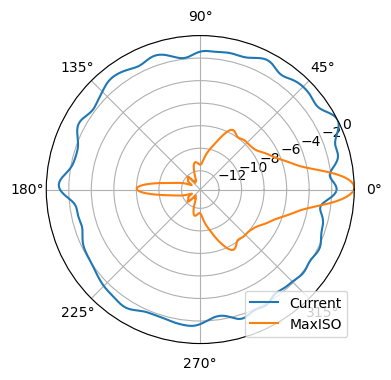

In [121]:
# directivity index of the maxISO beamformer
mic_pos = room.mic_array.R # [3 x I]
ell_ii = np.linalg.norm(mic_pos[:,:,None] - mic_pos[:,None,:], axis=0) # [I x I]
Gamma = np.sinc(2 * np.pi * freqs[:,None,None] * ell_ii[None] / room.c) # [F x I x I]
w_r = []
for i in range(nChan):
    w = mvdr_weights(room.sources[0].position[:,None], room.mic_array.R, room.c, freqs[1:], Gamma[1:], i, True)
    w = np.concatenate([np.zeros((1, w.shape[1])), w], axis=0)
    w_r.append(w)
w_r = np.stack(w_r, axis=-1)
w_iso = w_r[:,:,ref_mic_idx]

# compute the beampatter
beampatter_circ_iso = np.zeros((nDoas, nFreq))
for i in range(nDoas):
    steering_vector = compute_steering_vector(cart_pts_circ[:,[i]], mic_pos, room.c, freqs, mode="near")
    beampatter_circ_iso[i,:] = np.abs(np.einsum('fi,fji->fj', w_iso.conj(), steering_vector)[:,0])**2

B_iso = 10 * np.log10(beampatter_circ_iso.sum(-1)) - 10 * np.log10(beampatter_circ_iso.sum(-1).max())
B_curr = 10 * np.log10(beampatter_circ.sum(-1) / beampatter_circ.sum(-1).max())

plt.figure(figsize=(4, 4))
ax = plt.subplot(111, polar=True)
ax.plot(azimuths, B_curr, label="Current")
ax.plot(azimuths, B_iso, label="MaxISO")
plt.legend()

DI_iso = B_iso.sum() / B_curr.sum()
print("Directivity index of MaxISO: ", DI_iso)

results_dict_doa['DI_ratio_iso'] = DI_iso
results_dict_doa['beampattern_curr'] = B_curr.tolist()

# Save results

In [ ]:
df_results_image = pd.DataFrame(results_dict_image)
df_results_image.to_csv(f"../results/results_SIR-{SIR}_bf-{bf_criterion}_per_image.csv", index=False)
df_results_azimuth = pd.DataFrame(results_dict_doa)
df_results_azimuth.to_csv(f"../results/results_SIR-{SIR}_bf-{bf_criterion}_per_azimuth.csv", index=False)